In [1]:
# import necessary modules
# uncomment to get plots displayed in notebook
%matplotlib inline

### import class wrapper

from classy import Class

### math stuff
import numpy as np

### plotting stuff
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

import tqdm as tqdm

In [2]:
### Plot helpers

plt.rcParams.update({
    "text.usetex": True,                      # Use LaTeX to render all text
    "text.latex.preamble": r"\usepackage{amsmath}", # Load amsmath for advanced math typography
    "font.family": "serif",                   # Use a serif font for the main text
    "font.serif": ["Computer Modern Roman"],  # Match standard LaTeX default font
    "font.size": 14,                          # Standard font size for scientific papers
    "axes.labelsize": 14,                     # Size of the x and y axis labels
    "xtick.labelsize": 12,                     # Size of the x-tick labels
    "ytick.labelsize": 12,                     # Size of the y-tick labels
    "legend.fontsize": 12,                     # Size of the legend text
    "figure.titlesize": 16                    # Size of the figure's main title
})

# colorblind-friendly palette
colors_colorblind = ['#377eb8', '#ff7f00', '#4daf4a',
          '#f781bf', '#a65628', '#984ea3',
          '#999999', '#e41a1c', '#dede00']

In [3]:
# =======================
# BASE COSMOLOGY: Planck 2015 TT,TE,EE+lowE
# =======================
h_fixed     = 0.6727
theta_s_100 = 1.041783
omega_b     = 0.022383
omega_cdm0  = 0.12011
tau_reio    = 0.0543
A_s         = 2.1005829616811546e-9
n_s         = 0.96605

base_params = {
    "theta_s_100": theta_s_100,
    "omega_b": omega_b,
    "omega_cdm": omega_cdm0,
    "A_s": A_s,
    "n_s": n_s,
    "tau_reio": tau_reio,
}

In [4]:
### RUN LCDM for comparison first
lcdm = Class()
lcdm.set(base_params) 
lcdm.set({
    "output": "tCl,pCl,lCl,mPk",
    "l_max_scalars": 2500,
    'lensing': 'yes',
})
lcdm.compute()

### Read background quantities for LCDM

bg_lcdm = lcdm.get_background()
z_lcdm = bg_lcdm['z']
a_lcdm = 1/(1+z_lcdm)
rho_cdm_lcdm = bg_lcdm['(.)rho_cdm']
rho_g_lcdm = bg_lcdm['(.)rho_g']
H_lcdm = bg_lcdm['H [1/Mpc]']
rho_tot_lcdm = bg_lcdm['(.)rho_tot']
z_eq_lcdm = lcdm.get_current_derived_parameters(['z_eq'])
print(f"Redshift of matter-radiation equality in LCDM: {z_eq_lcdm['z_eq']:.2f}")

cl_lcdm = lcdm.lensed_cl(2500)
ll_lcdm = cl_lcdm['ell'][2:]
clTT_lcdm = cl_lcdm['tt'][2:]
clEE_lcdm = cl_lcdm['ee'][2:]
clTE_lcdm = cl_lcdm['te'][2:]


Redshift of matter-radiation equality in LCDM: 3405.82


In [5]:
### Constants

num_of_gigayears = 0.1 # REMOVE, Irrelevant in this formulation
tau_acc = num_of_gigayears*3600*24*365*1e9 # REMOVE, Irrelevant in this formulation
f_acc = 0.1 # rho_acc/rho_cdm today
m_dcdm = 1e16
m_wdm = 1e16 # in accDM model it should be the same as mass of the DM particle before acceleration, but this implementation is more general and allows to set them independently
kappa = 1
a_t = 0.1

In [6]:
# mass_values = [1e11, 2e11, 5e11, 1e12]
# eta_list = 10**11/np.array(mass_values)

mass = 5e11
eta = 0.1 #10**11/mass

k_values = [1e-3, 1e-2, 1e-1, 1]
k_values_CLASS = ', '.join([str(k) for k in k_values])
ncdm_q_steps = 601
a_rec = 1/(1+1090)

gauge = 'synchronous'
approximations = ['boltzmann', 'fluid']


In [7]:
### Run CLASS ###

# Output dictionaries
AccCLASS = {}
bgAcc, pbAcc, clAcc = {}, {}, {}

output_settings = {
        'output': 'tCl, pCl, lCl, mPk',
        'l_max_scalars': 2500,
        'lensing': 'yes',
        'k_output_values': k_values_CLASS
}

bg_settings = {
    'omega_cdm': omega_cdm0*(1+f_acc*(1-a_rec**kappa)/(1+(a_rec/a_t)**kappa))**(-1),
}   

accDM_settings = {
    'vary_Gamma_acc': 'yes',               # Use the more general formulation
    'kappa_acc':      kappa,               # 
    'a_t_acc':        a_t,                 # Scale factor at which the acceleration happens
    'f_acc':          f_acc,               # Set the fraction of all DM that can be accelerated, i.e. f_acc = rho_acc/(rho_c+rho_acc) in far past. It's a bit weird to set it like this, but eh
    'eta_acc':        eta,                 # Energy gain of the WDM component defined via the enrgy right after acceleration E_wdm = m_wdm(1+\approx)
    "tau_acc":        tau_acc,             # REMOVE, Irrelevant in this formulation
    "m_acc_in_GeV":   mass,               # accDM mass in GeV
    "m_cdm_in_GeV":   mass,              # DCDM mass in GeV, in accDM case these two masses should be the same, but this implementation is more general
}

ncdm_settings = {
    # ncdm params [0] is for the neutrinos, [1] is for the WDM component
    "N_ncdm":                   1,                       # accDM is always the last ncdm species, so it has index N_ncdm-1, here we sset N_ncdm=2 to have both massive neutrinos and accDM
    "deg_ncdm":                 1,                  # 3 neutrino species and 1 degrees of freedom for the WDM component 
    "m_ncdm":                   mass*1e9,    # Set a small mass for the neutrino species and a large mass for the WDM component (in eV), the 2nd entry shuld be irrelevant as m_ncdm[1] should be overwritten in the code by m_wdm_in_GeV
    "T_ncdm":                   1,            # Set the same temperature for the WDM component as for the neutrinos,
    "N_ur":                     3.044,                 # Set the number of massless neutrino species to 0 since we are including them as ncdm species
    "ncdm_quadrature_strategy": 4,                  # Quadrature strategy for each ncdm species, 0 (CLASS auto quadrature) for neutrinos, 4 for WDM (logarithmic Simpson, added in CLASS by me based on 2102.12498 -- the repo linked in this paper has WRONG IMPLEMENTATION!)      
    "ncdm_N_momentum_bins" :    ncdm_q_steps, 
    #"ncdm_fluid_approximation": 0, # Use fluid approximation for the WDM component if approx=='fluid', otherwise use Boltzmann hierarchy
    "switch_on_eq_delta_p_acc": 'no', 
    "switch_off_shear_acc": 'yes', 
}

other_settings = {
    'reionization_z_start_max': 80,      # Default is 50, 80 is the minimal value that works for the chosen values if we set tau_reio to Planck 2018 value, it just widens the bracket so that this doesn't cause issue with shooting for h
    'evolver': 0,
    'gauge': gauge,
    'get_perturbations_in_current_gauge': 'yes',
}

for approx in tqdm.tqdm(approximations):
    #mass = 10**11/approx
    if (mass*(1+eta) > 1e19) or (mass > 1e19):
        print(f"Warning: energy of the WDM particle after acceleration is {mass*(1+eta):.2e} GeV, which is above the Planck scale.")
        break
    
    AccCLASS = Class()
    AccCLASS.set(base_params)
    AccCLASS.set(output_settings, **bg_settings, **accDM_settings, **ncdm_settings, **other_settings)
    AccCLASS.set({
        "ncdm_fluid_approximation": 0 if approx=='fluid' else 3,
    })
    AccCLASS.compute()
    bgAcc[approx] = AccCLASS.get_background()
    pbAcc[approx] = AccCLASS.get_perturbations()
    clAcc[approx] = AccCLASS.lensed_cl(2500)


100%|██████████| 2/2 [01:26<00:00, 43.35s/it]


In [8]:
z, a, H = {}, {}, {}
rho_g, rho_cdm, rho_dcdm, rho_b, rho_ur, rho_lambda = {}, {}, {}, {}, {}, {}
rho_acc, p_acc = {}, {}
smooth_rho_acc, smooth_p_acc = {}, {}
rho_nu = {}
rho_tot, rho_crit = {}, {}
z_eq = {}

delta_cdm, delta_g, delta_b, delta_ur, delta_nu = {}, {}, {}, {}, {}
delta_dcdm, delta_acc, delta_dr = {}, {}, {}
rho_plus_p_theta = {}
ll, clTT, clEE, clTE, clPP = {}, {}, {}, {}, {}

phi, phi_prime, psi = {}, {}, {}
h_prime, eta,  eta_prime = {}, {}, {}
delta_rho = {}

CH, CM = {}, {}

for approx in approximations:
    # a, z, and H
    H[approx] = bgAcc[approx]['H [1/Mpc]']
    z[approx] = bgAcc[approx]['z']
    a[approx] = 1/(1+z[approx])
    
    # The usual components of the universe
    rho_g[approx] = bgAcc[approx]['(.)rho_g'] 
    rho_b[approx] = bgAcc[approx]['(.)rho_b']
    rho_cdm[approx] = bgAcc[approx]['(.)rho_cdm']
    rho_lambda[approx] = bgAcc[approx]['(.)rho_lambda']
    rho_ur[approx] = bgAcc[approx]['(.)rho_ur']
    # rho_nu[approx] = bgAcc[approx]['(.)rho_ncdm[0]']

    # Energy densities of the DCDM and WDM components and the pressure of the WDM component
    rho_dcdm[approx] = bgAcc[approx]['(.)rho_acc_cdm']
    rho_acc[approx] = bgAcc[approx]['(.)rho_ncdm[0]']
    p_acc[approx] = bgAcc[approx]['(.)p_ncdm[0]']

    # Total and critical energy densities
    rho_tot[approx] = bgAcc[approx]['(.)rho_tot']
    rho_crit[approx] = bgAcc[approx]['(.)rho_crit']
    
    z_eq[approx] = AccCLASS.get_current_derived_parameters(['z_eq'])

    for i in range(len(k_values)):
        scalar_data = pbAcc[approx]['scalar'][i]  # Scalar perturbations for selected k-values
        # print(scalar_data.keys())
        a[approx, k_values[i]] = scalar_data['a']
        
        ### Interpolate H onto this a grid
        
        H_interp = interp1d(a[approx], H[approx], kind='cubic', fill_value="extrapolate")
        H[approx, k_values[i]] = H_interp(a[approx, k_values[i]])
    
        # Extract perturbation quantities
        delta_cdm[approx, k_values[i]] = scalar_data['delta_cdm']
        delta_g[approx, k_values[i]] = scalar_data['delta_g']
        delta_b[approx, k_values[i]] = scalar_data['delta_b']
        delta_ur[approx, k_values[i]] = scalar_data['delta_ur']
        # delta_nu[approx, k_values[i]] = scalar_data['delta_ncdm[0]']
        
        delta_dcdm[approx, k_values[i]] = scalar_data['delta_dcdm']
        delta_acc[approx, k_values[i]] = scalar_data['delta_ncdm[0]']
        delta_rho[approx, k_values[i]] = scalar_data['delta_rho_tot'] # For testing
        if gauge == 'synchronous':
            eta[approx, k_values[i]] = scalar_data['eta'] # For testing
            h_prime[approx, k_values[i]] = scalar_data['h_prime']
            eta_prime[approx, k_values[i]] = scalar_data['eta_prime']  
            rho_plus_p_theta[approx, k_values[i]] = scalar_data['rho_plus_p_theta'] # For testing
            CH[approx, k_values[i]] = k_values[i]**2*eta[approx, k_values[i]]+0.5*a[approx, k_values[i]]*H[approx, k_values[i]]*h_prime[approx, k_values[i]]+1.5*a[approx, k_values[i]]**2*delta_rho[approx, k_values[i]]
            CM[approx, k_values[i]] = k_values[i]**2*eta_prime[approx, k_values[i]]-3*a[approx, k_values[i]]**2/2*rho_plus_p_theta[approx, k_values[i]]
        else:
            phi[approx, k_values[i]] = scalar_data['phi']
            phi_prime[approx, k_values[i]] = scalar_data['phi_prime']
            psi[approx, k_values[i]] = scalar_data['psi']
            CM[approx, k_values[i]] = -k_values[i]**2*(phi_prime[approx, k_values[i]]+H[approx, k_values[i]]*psi[approx, k_values[i]]); #4piGa^2(rho_plus_p)delta... 
        ### POWER SPECTRUM
        
    ll[approx] = clAcc[approx]['ell'][2:]
    clTT[approx] = clAcc[approx]['tt'][2:]
    clEE[approx] = clAcc[approx]['ee'][2:]
    clTE[approx] = clAcc[approx]['te'][2:]
    clPP[approx] = clAcc[approx]['pp'][2:]

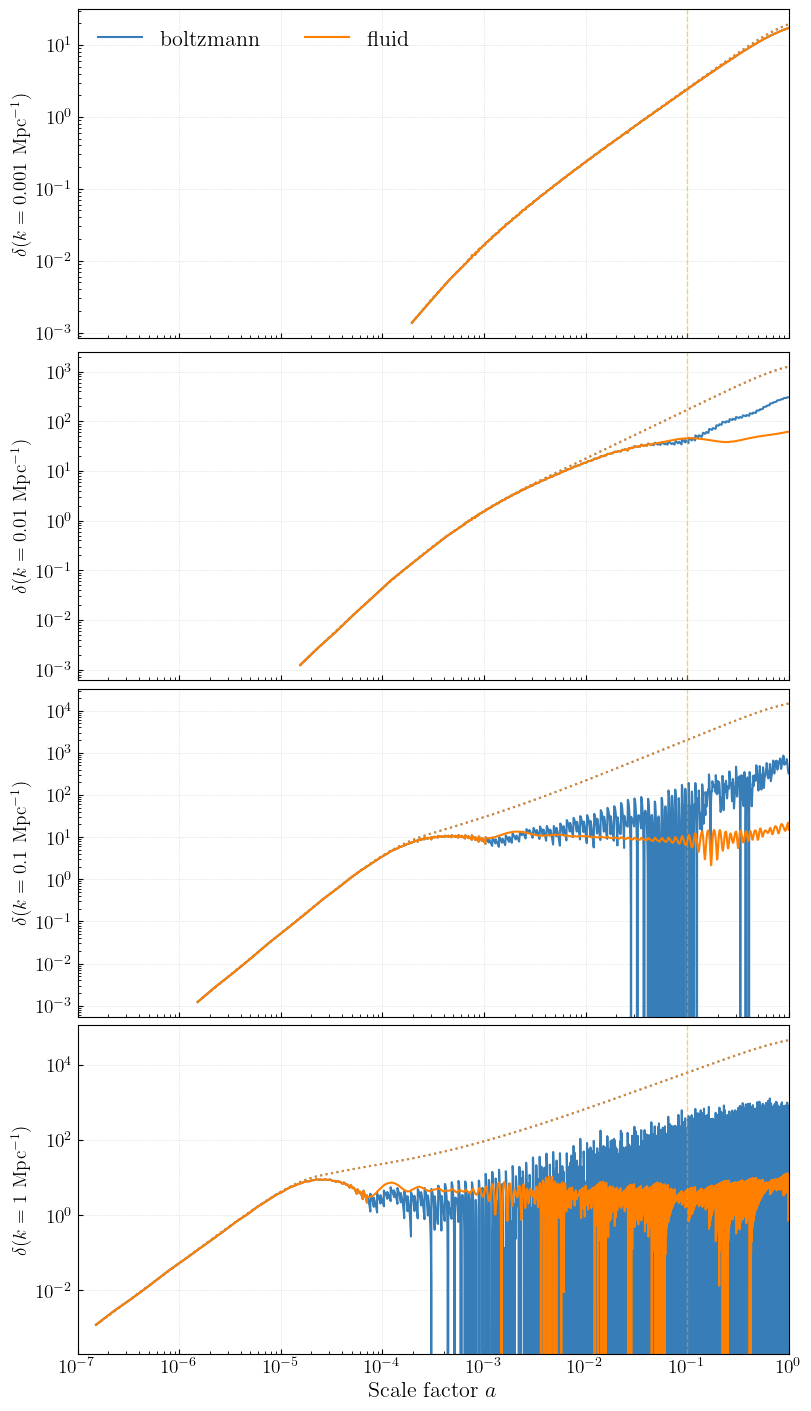

In [9]:
plt.style.use('tableau-colorblind10') # Good for accessibility

fig, axs = plt.subplots(len(k_values), 1, figsize=(8, 3.5*len(k_values)), 
                        sharex=True, constrained_layout=True)

# Define a color map for eta_list to ensure consistency [cite: 462, 464]
colors = colors_colorblind[:len(approximations)]

for i, k in enumerate(k_values):
    for j, approx in enumerate(approximations):
        a_mon = a[approx, k]
        axs[i].plot(a_mon, -delta_acc[approx, k], color=colors[j], 
                    ls='-', label=rf'{approx}')
        axs[i].plot(a_mon, -delta_dcdm[approx, k], color=colors[j], 
                    ls=':', alpha=0.8)

    # a_eq = 1/(1 + z_eq[approx]['z_eq'])
    # axs[i].axvline(x=a_eq, ls='--', lw=1, color='gray', alpha=0.5)
    axs[i].axvline(x=a_t, ls='--', lw=1, color='orange', alpha=0.5)
    
    # Labeling and Scales [cite: 2342, 2347]
    axs[i].set_xscale('log')
    axs[i].set_xlim(1e-7, 1)
    axs[i].set_yscale('log')
    axs[i].set_ylabel(rf'$\delta(k={k}$ Mpc$^{{-1}}$)', fontsize=14)
    
    # Grid and Ticks refinement [cite: 661, 738]
    axs[i].grid(True, which='major', ls=':', lw=0.5, alpha=0.6)
    axs[i].tick_params(direction='in', which='both', labelsize=14)

    # Only one legend for the whole column [cite: 836, 851]
    if i == 0:
        axs[i].legend(fontsize=16, loc='upper left', frameon=False, ncol=2)

axs[-1].set_xlabel(r'Scale factor $a$', fontsize=16)

# Save with publication-ready resolution [cite: 1784, 1800]
# plt.savefig("perturbations.pdf", dpi=600)
plt.show()

/tmp/ipykernel_295473/40870206.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend(fontsize=16, loc='upper left', frameon=False, ncol=2)


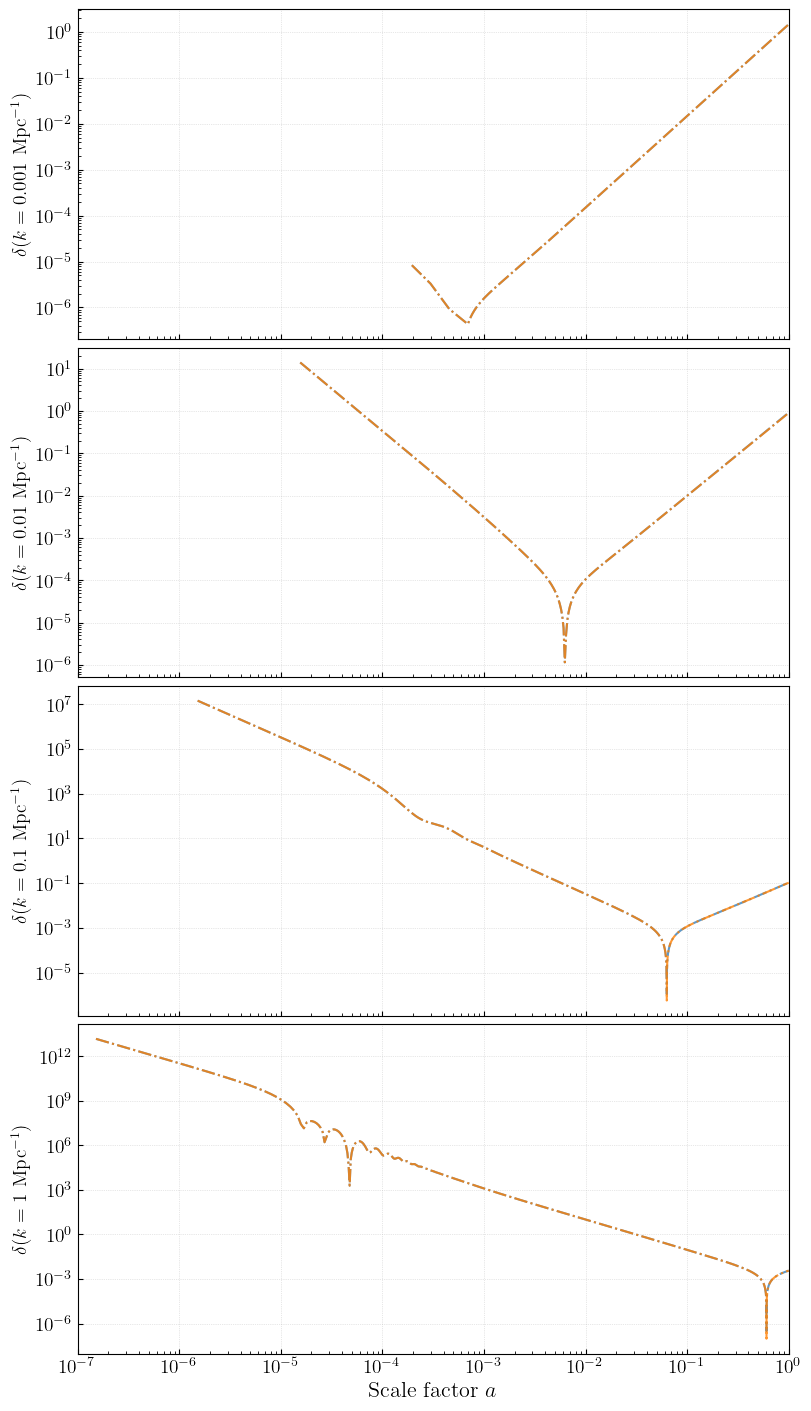

In [10]:
plt.style.use('tableau-colorblind10') # Good for accessibility

fig, axs = plt.subplots(len(k_values), 1, figsize=(8, 3.5*len(k_values)), 
                        sharex=True, constrained_layout=True)

# Define a color map for eta_list to ensure consistency [cite: 462, 464]
colors = colors_colorblind[:len(approximations)]

for i, k in enumerate(k_values):
    for j, approx in enumerate(approximations):
        a_mon = a[approx, k]
        H_mon = H[approx, k]
        
        if gauge == 'synchronous':
            # axs[i].plot(a_mon, -eta_prime[approx, k], color=colors[j], 
            #             ls='-', label=rf'{approx}')
            # axs[i].plot(a_mon, h_prime[approx, k], color=colors[j], 
            #             ls='--', alpha=0.8)
            # axs[i].plot(a_mon, CH[approx, k], color=colors[j],
            #             ls='-.', alpha=0.8)
            # axs[i].plot(a_mon, 3*a_mon**2*rho_plus_p_theta[approx, k]/2, color=colors[j],
            #             ls='-', alpha=0.8)
            # axs[i].plot(a_mon, k**2*eta_prime[approx, k], color=colors[j],
            #             ls='-.', alpha=0.8)
            # axs[i].plot(a_mon, k**2*eta[approx, k], color=colors[j],
            #             ls='--', alpha=0.8)
            # axs[i].plot(a_mon, 0.5*a_mon*H_mon*h_prime[approx, k], color=colors[j],
            #             ls='-', label=rf'{approx}')
            # axs[i].plot(a_mon, 1.5*a_mon**2*delta_rho[approx, k], color=colors[j],
            #             ls=':', label=rf'{approx}')
            axs[i].plot(a_mon, np.abs(CH[approx, k]), color=colors[j],
                        ls='-.', alpha=0.8)
        else:
            continue
            # axs[i].plot(a_mon, phi[approx, k], color=colors[j], 
            #             ls='-', label=rf'{approx}')
            # axs[i].plot(a_mon, phi_prime[approx, k], color=colors[j], 
            #             ls=':', alpha=0.8)
            # axs[i].plot(a_mon, psi[approx, k], color=colors[j], 
            #             ls='-.', alpha=0.8)

    # Specific ornaments for scientific context [cite: 831, 832]
    a_eq = 1/(1 + z_eq[approx]['z_eq'])
    # axs[i].axvline(x=a_eq, ls='--', lw=1, color='gray', alpha=0.5)
    # axs[i].axvline(x=a_t, ls='--', lw=1, color='orange', alpha=0.5)
    
    # Labeling and Scales [cite: 2342, 2347]
    axs[i].set_xscale('log')
    axs[i].set_xlim(1e-7, 1)
    axs[i].set_yscale('log')
    axs[i].set_ylabel(rf'$\delta(k={k}$ Mpc$^{{-1}}$)', fontsize=14)
    
    # Grid and Ticks refinement [cite: 661, 738]
    axs[i].grid(True, which='major', ls=':', lw=0.5, alpha=0.6)
    axs[i].tick_params(direction='in', which='both', labelsize=14)

    # Only one legend for the whole column [cite: 836, 851]
    if i == 0:
        axs[i].legend(fontsize=16, loc='upper left', frameon=False, ncol=2)

axs[-1].set_xlabel(r'Scale factor $a$', fontsize=16)

# Save with publication-ready resolution [cite: 1784, 1800]
# plt.savefig("perturbations.pdf", dpi=600)
plt.show()

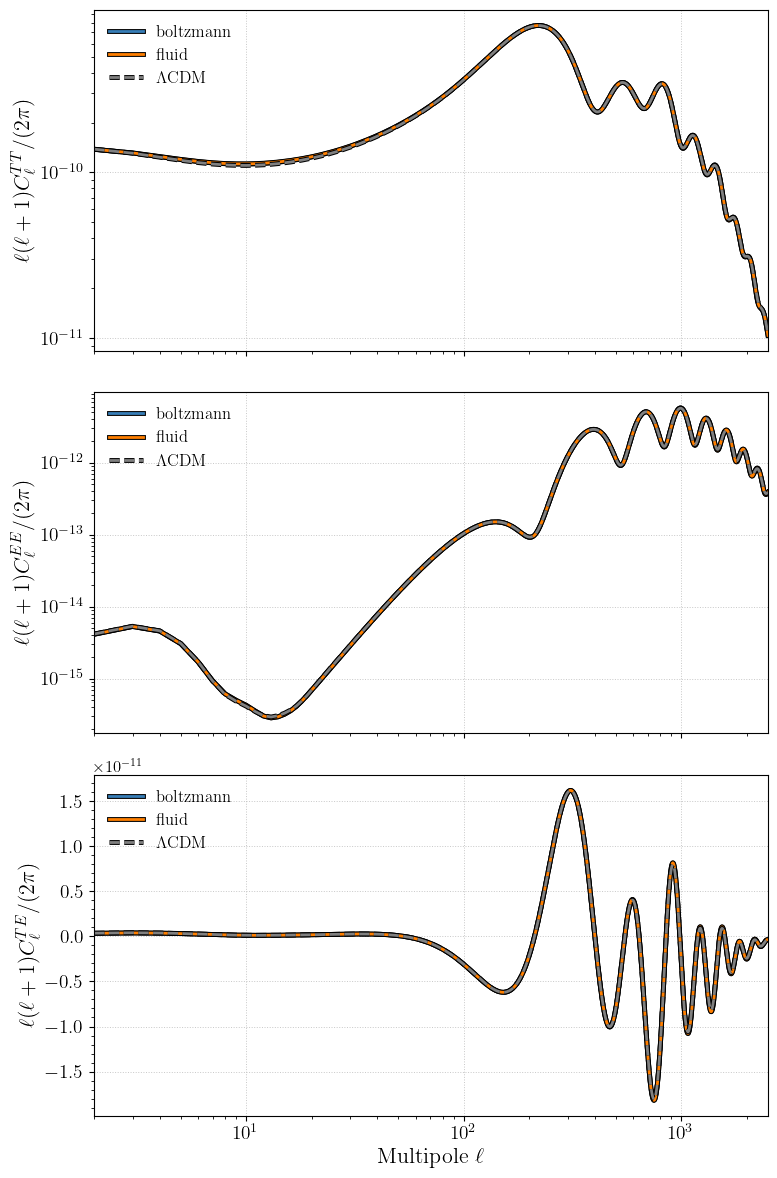

In [11]:
### PLot CMB power spectra for different values of gauge
fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

for i, (cl, label) in enumerate(zip([clTT, clEE, clTE], ['TT', 'EE', 'TE'])):
    for j, approx in enumerate(approximations):
        axs[i].plot(ll[approx], ll[approx]*(1+ll[approx])*cl[approx]/(2*np.pi), label=rf'{approx}', 
                    color=colors_colorblind[j], linewidth=2, path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
    
    if label == 'TT':
        axs[i].plot(ll_lcdm, ll_lcdm*(1+ll_lcdm)*clTT_lcdm/(2*np.pi), label=r'$\Lambda$CDM', color='grey', linewidth=2, ls='--', path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
    elif label == 'EE':
        axs[i].plot(ll_lcdm, ll_lcdm*(1+ll_lcdm)*clEE_lcdm/(2*np.pi), label=r'$\Lambda$CDM', color='grey', linewidth=2, ls='--', path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
    elif label == 'TE':
        axs[i].plot(ll_lcdm, ll_lcdm*(1+ll_lcdm)*clTE_lcdm/(2*np.pi), label=r'$\Lambda$CDM', color='grey', linewidth=2, ls='--', path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])   
    
    axs[i].set_xscale('log')
    axs[i].set_xlim(2, 2500)    
    axs[i].set_yscale('log') if label != 'TE' else axs[i].set_yscale('linear')
    axs[i].set_ylabel(rf'$\ell(\ell+1)C_\ell^{{{label}}}/(2\pi)$', fontsize=16)
    axs[i].grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    axs[i].minorticks_on()
    axs[i].tick_params(axis='both', which='major', labelsize=14)
    axs[i].legend(fontsize=12, loc='upper left', frameon=False)

axs[-1].set_xlabel(r'Multipole $\ell$', fontsize=16)

plt.tight_layout()
plt.show()

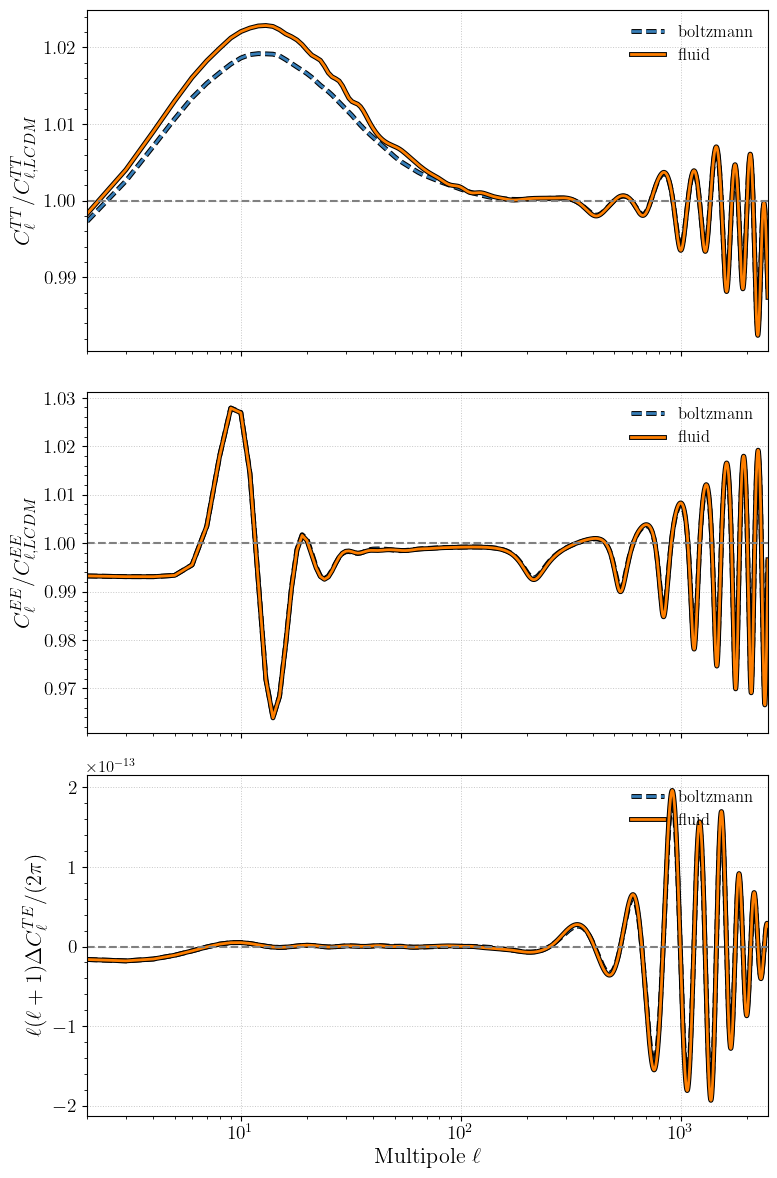

In [12]:
### PLot CMB power spectra for different values of approx
fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex = True)

for i, (cl, label) in enumerate(zip([clTT, clEE, clTE], ['TT', 'EE', 'TE'])):
    for j, approx in enumerate(approximations):
        if approx == 'fluid':
            ls = '-'
        else:
            ls = '--'
        
        if cl is clTE:
            cl_lcdm = clTE_lcdm
        elif cl is clTT:
            cl_lcdm = clTT_lcdm
        elif cl is clEE:
            cl_lcdm = clEE_lcdm
        
        if cl is clTE:
            axs[i].plot(ll[approx], ll[approx]*(1+ll[approx])*(cl[approx]-cl_lcdm)/(2*np.pi), 
                        label=rf'{approx}', 
                        color=colors_colorblind[j], 
                        linewidth=2, linestyle = ls, 
                        path_effects=[pe.withStroke(linewidth=3.5, foreground='black')]) 
        else:
            axs[i].plot(ll[approx], cl[approx]/cl_lcdm, 
                        label=rf'{approx}', 
                        color=colors_colorblind[j], 
                        linewidth=2, linestyle = ls,
                        path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])
    
    if cl is clTE:
        axs[i].axhline(0, color='grey', linestyle='--')
        axs[i].set_yscale('linear')
        axs[i].set_ylabel(rf'$\ell(\ell+1)\Delta C_\ell^{{{label}}}/(2\pi)$', fontsize=16)
    else:
        axs[i].axhline(1, color='grey', linestyle='--')
        axs[i].set_yscale('linear')
        axs[i].set_ylabel(rf'$C_\ell^{{{label}}}/C_{{\ell, LCDM}}^{{{label}}}$', fontsize=16)
    
    axs[i].set_xscale('log')
    axs[i].set_xlim(2, 2500)    
    axs[i].grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    axs[i].minorticks_on()
    axs[i].tick_params(axis='both', which='major', labelsize=14)
    axs[i].legend(fontsize=12, loc='upper right', frameon=False)
    
axs[2].set_xlabel(r'Multipole $\ell$', fontsize=16)
plt.tight_layout()
plt.show()

KeyError: 'Boltzmann hierarchy'

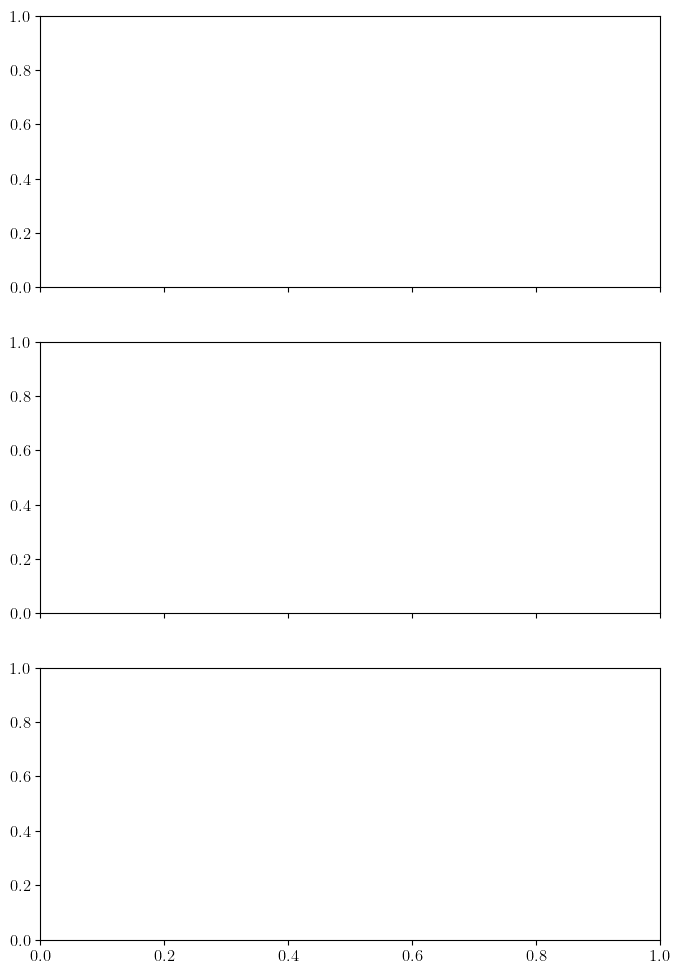

In [13]:
### PLot CMB power spectra for different values of approx
fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex = True)

for i, (cl, label) in enumerate(zip([clTT, clEE, clTE], ['TT', 'EE', 'TE'])):
    if approx == 'fluid':
        ls = '-'
    else:
        ls = '--'
    
    if cl is clTE:
        cl_lcdm = clTE_lcdm
    elif cl is clTT:
        cl_lcdm = clTT_lcdm
    elif cl is clEE:
        cl_lcdm = clEE_lcdm
    
    if cl is clTE:
        axs[i].plot(ll[approx], ll[approx]*(1+ll[approx])*(cl['fluid']-cl['Boltzmann hierarchy'])/(2*np.pi), 
                    color='black', 
                    linewidth=2, linestyle = ls, 
                    path_effects=[pe.withStroke(linewidth=3.5, foreground='black')]) 
    else:
        axs[i].plot(ll['fluid'], 100*(cl['fluid']-cl['Boltzmann hierarchy'])/cl['Boltzmann hierarchy'], 
                    color='black', 
                    linewidth=2, linestyle = ls,
                    path_effects=[pe.withStroke(linewidth=3.5, foreground='black')])

    if cl is clTE:
        axs[i].axhline(0, color='grey', linestyle='--')
        axs[i].set_yscale('linear')
        axs[i].set_ylabel(rf'$\ell(\ell+1)\Delta C_\ell^{{{label}}}/(2\pi)$', fontsize=16)
    else:
        axs[i].axhline(0, color='grey', linestyle='--')
        axs[i].set_yscale('linear')
        axs[i].set_ylabel(rf'$\Delta C_\ell^{{{label}}}$', fontsize=16)

    axs[i].set_xscale('log')
    axs[i].set_xlim(2, 2500)  
    axs[i].grid(which='major', linestyle=':', linewidth=0.7, alpha=0.7)
    axs[i].minorticks_on()
    axs[i].tick_params(axis='both', which='major', labelsize=14)
# axs[i].legend(fontsize=12, loc='upper right', frameon=False)
    
axs[2].set_xlabel(r'Multipole $\ell$', fontsize=16)

fig.suptitle('Relative difference between fluid approximation and Boltzmann hierarchy', fontsize=18)
plt.tight_layout()
plt.show()